In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pylab as pl
from matplotlib import collections as mc
from matplotlib.lines import Line2D


In [18]:
# Словарь цветов для разных состояний клиента.
# Добавлен цвет по умолчанию 'gray' для неизвестных состояний.
gl_colors = {
    "unavailable:": 'black',
    "idle:": 'red',
    "busy:Project1": 'green',
    "busy:Project2": 'blue'
}

def draw_for_clients(dir_path, client_names, experiment_indices=[80], total_experiments=None):
    """
    Рисует временную шкалу состояний для указанных клиентов по данным из нескольких
    файлов экспериментов. Клиенты ранжируются по времени начала их первого события.

    :param dir_path: Путь к директории с файлами *.csv.
    :param client_names: Список имен клиентов для визуализации.
    :param experiment_indices: Список или диапазон индексов экспериментов для обработки.
    :param total_experiments: Общее количество экспериментов (для корректного позиционирования).
                              Если None, вычисляется автоматически.
    """
    if not isinstance(client_names, list):
        client_names = [client_names]

    if total_experiments is None:
        total_experiments = len(experiment_indices)

    # --- Шаг 1: Сбор всех данных в один DataFrame ---
    all_data_frames = []
    for ind_expr in experiment_indices:
        try:
            # Улучшено: использование pathlib для работы с путями
            file_path = f"{dir_path}/execute_stat_{ind_expr}.csv"
            data_execs = pd.read_csv(file_path)
            # Добавляем индекс эксперимента для корректного расчёта y-координаты
            data_execs['exp_idx'] = experiment_indices.index(ind_expr)
            all_data_frames.append(data_execs)
        except FileNotFoundError:
            print(f"Предупреждение: Файл '{file_path}' не найден. Пропускаем.")
            continue
    
    if not all_data_frames:
        print("Не найдено данных для указанных экспериментов.")
        return
        
    full_data = pd.concat(all_data_frames, ignore_index=True)
    # Фильтруем данные только по нужным клиентам
    full_data = full_data[full_data['client'].isin(client_names)]

    if full_data.empty:
        print(f"Нет данных для отображения для клиентов: {client_names}.")
        return

    # --- Шаг 2: Определение времени старта и сортировка клиентов ---
    # Находим самое раннее время начала для каждого клиента
    min_starts = full_data.groupby('client')['start'].min()
    # Сортируем имена клиентов по времени начала (от раннего к позднему)
    sorted_clients = sorted(client_names, key=lambda name: min_starts.get(name, float('inf')))

    # --- Шаг 3: Подготовка сегментов для отрисовки в новом порядке ---
    lines = []
    colors = []
    seen_states = {}

    for client_idx, client_name in enumerate(sorted_clients):
        client_data = full_data[full_data['client'] == client_name]
        if client_data.empty:
            continue

        # Векторизованное создание сегментов
        y_positions = client_idx * (total_experiments + 1) + (total_experiments - 1 - client_data['exp_idx'])
        
        segments = [[(start, y), (end, y)] for start, end, y in zip(client_data['start'], client_data['end'], y_positions)]
        line_colors = [gl_colors.get(state_type, 'gray') for state_type in client_data['type']]
        
        lines.extend(segments)
        colors.extend(line_colors)

        # Сбор уникальных состояний для легенды
        for state_type in client_data['type'].unique():
            if state_type not in seen_states:
                seen_states[state_type] = gl_colors.get(state_type, 'gray')

    # --- Шаг 4: Отрисовка графика ---
    lc = mc.LineCollection(lines, colors=colors, linewidths=18)
    fig, ax = plt.subplots(figsize=(18, 2 + len(client_names) * len(experiment_indices)))
    ax.add_collection(lc)
    ax.autoscale()
    ax.margins(0.1)
    
    ax.set_title(f"Timeline for clients: {', '.join(client_names)}")
    ax.set_xlabel("Simulation Time (seconds)")
    ax.set_ylabel("Clients")
    
    # Настройка меток по оси Y для отображения отсортированных имен клиентов
    y_ticks = [i * (total_experiments + 1) + (total_experiments - 1) / 2 for i in range(len(sorted_clients))]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(sorted_clients)
    
    # Создание и настройка легенды
    legend_elements = [Line2D([0], [0], color=color, lw=4, label=state) for state, color in seen_states.items()]
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), prop={'size': 24})

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


Отрисовка таймлайнов для любого числа клиентов при 1 запуске симулятора

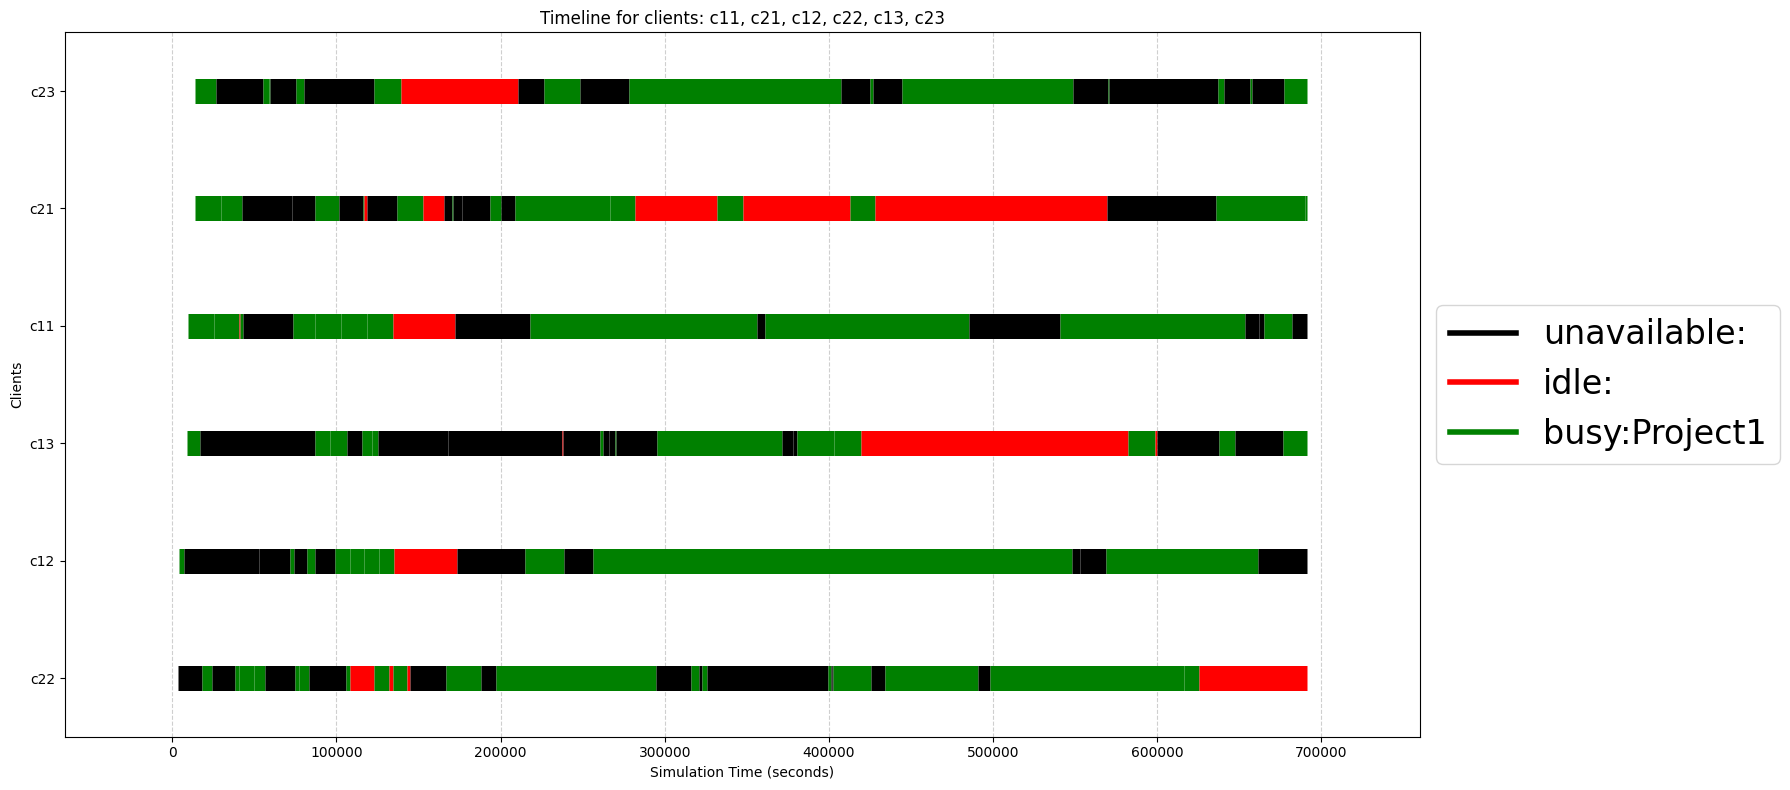

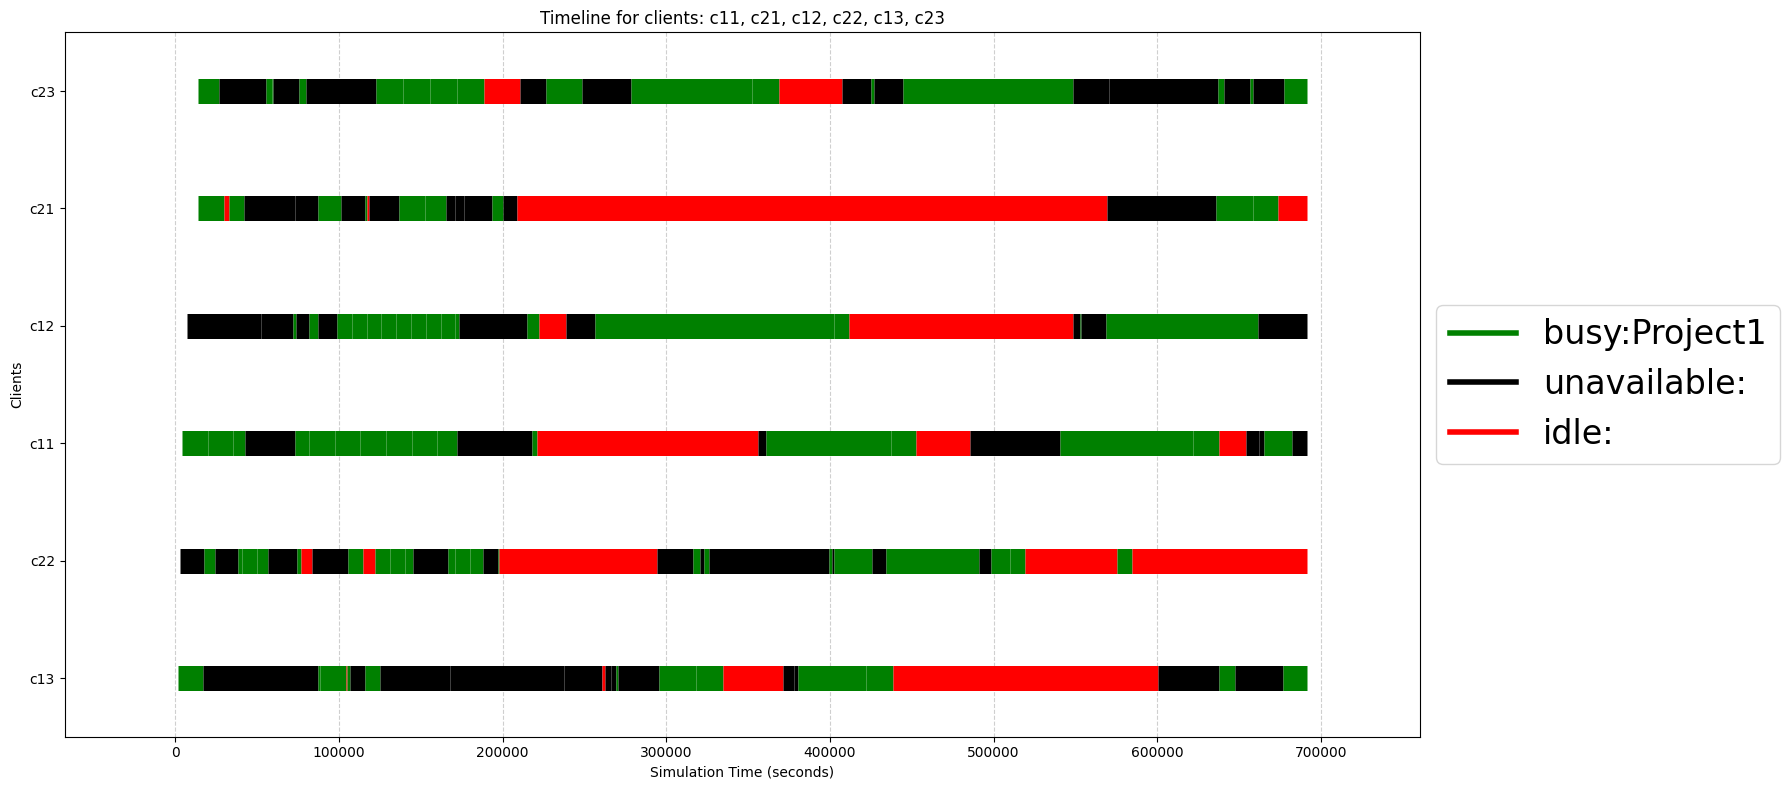

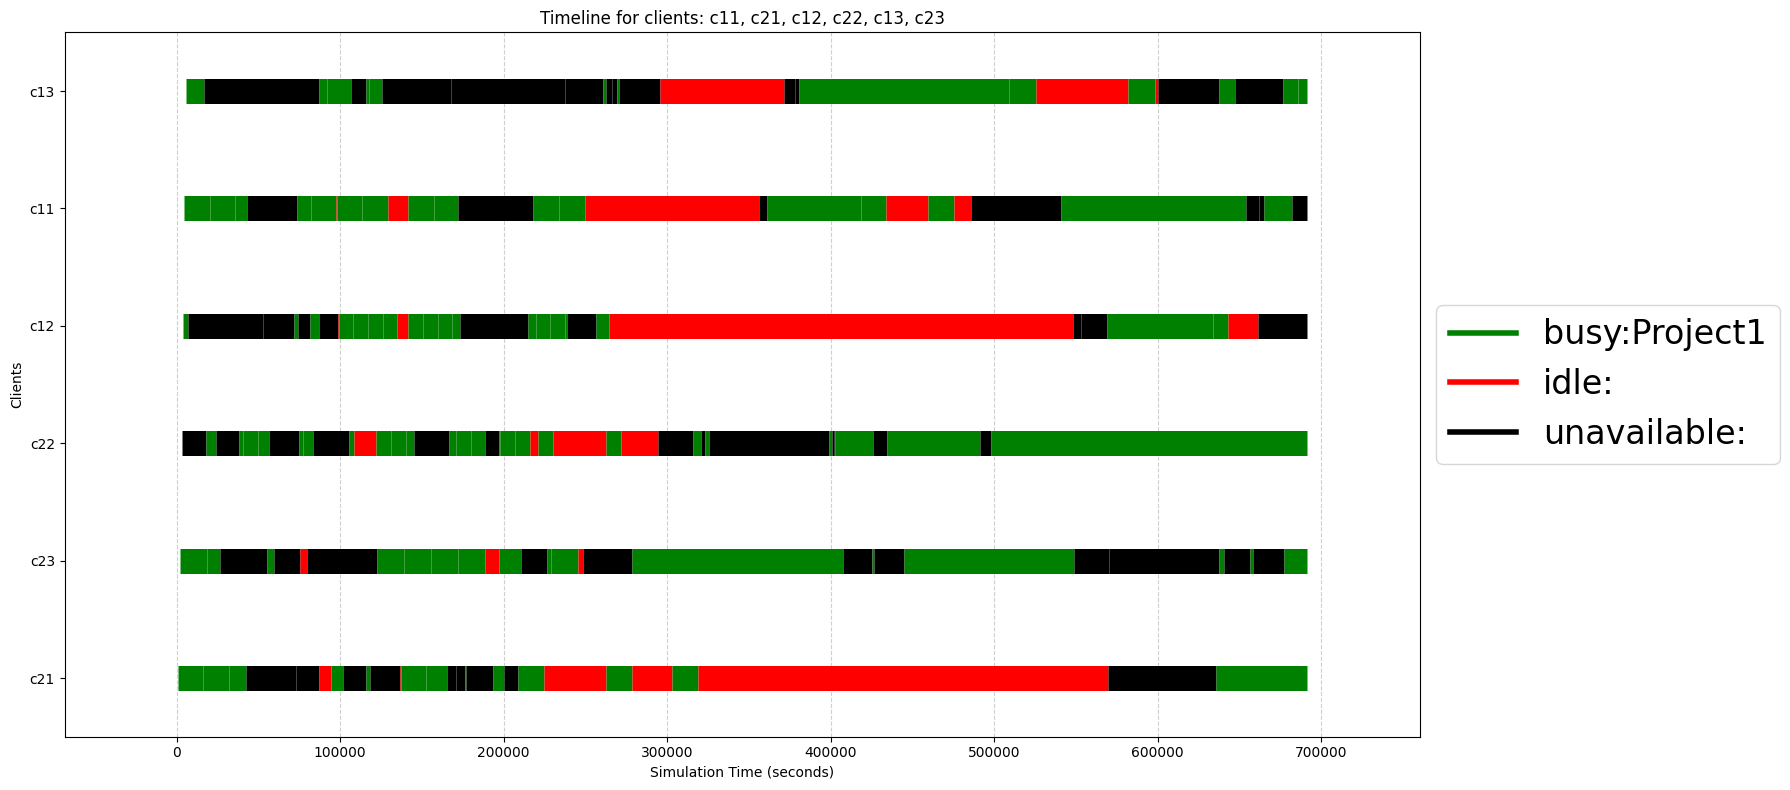

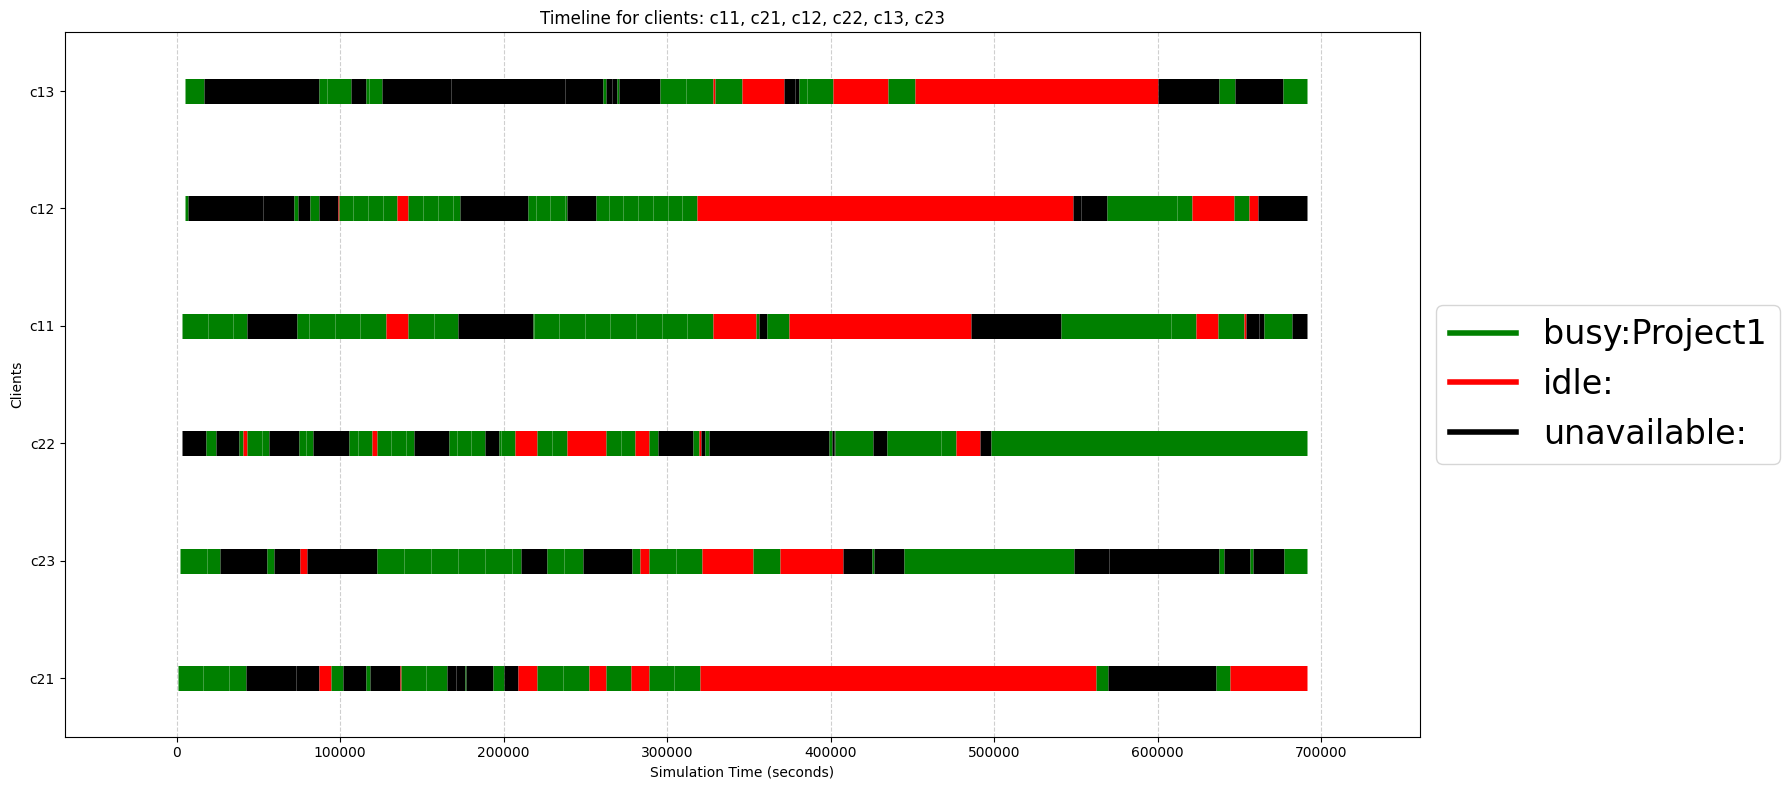

In [19]:
names = ['2025-11-15_09-40-14', '2025-11-15_09-43-55', '2025-11-15_09-47-16', '2025-11-15_09-50-08']
for name in names:
    draw_for_clients(name, ['c11', 'c21', 'c12', 'c22', 'c13', 'c23'])